# v0.3.34 STDP LTP/LTD Network Adaptation Tutorial


```python
import jaxfne as jtfne
```
This tutorial demonstrates STDP activity-dependent plasticity in a 100-neuron E-I spiking network, using the modular package-level APIs. Every scientific line calls a `jaxfne` object/function.

In [1]:
import jaxfne as jtfne
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Network Geometry and Initial Weights

We use `jtfne.make_ei_cloud_network` to generate random 3D positions inside a sphere/cloud, and initial synapse gains $W$ with E/I split and sign preservation.

In [2]:
n_neurons = 100
pos, exc_mask, inh_mask, W_init = jtfne.make_ei_cloud_network(n_neurons, seed=42)

print(f"Positions shape: {pos.shape}")
print(f"Excitatory count: {int(jnp.sum(exc_mask))}")
print(f"Inhibitory count: {int(jnp.sum(inh_mask))}")
print(f"Initial weight matrix shape: {W_init.shape}")

Positions shape: (100, 3)
Excitatory count: 70
Inhibitory count: 30
Initial weight matrix shape: (100, 100)


## 2. Triangular 6 Hz Stimulus Drive

We generate a triangular 6 Hz drive stimulus using the package stimulus API.

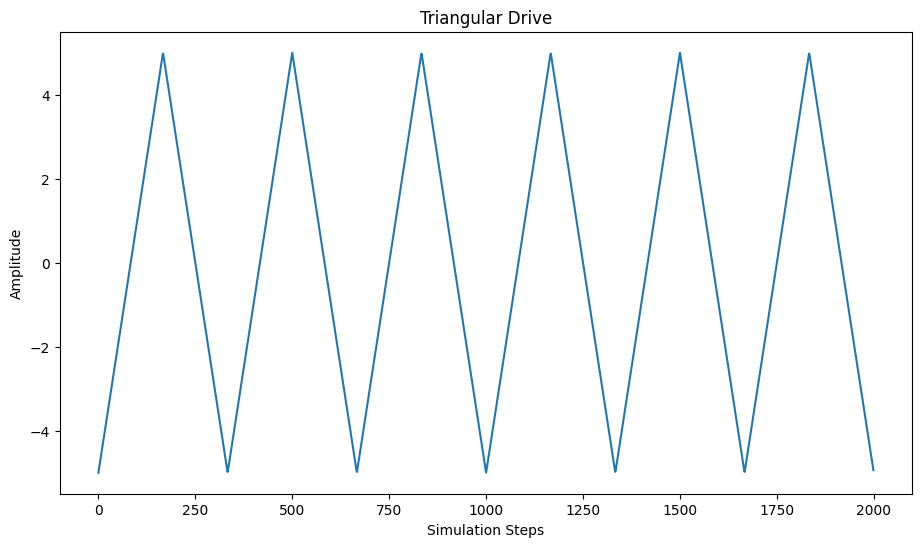

In [3]:
duration_ms = 1000.0
dt_ms = 0.5
stim = jtfne.triangular_drive(duration_ms, dt_ms, freq_hz=6.0, amplitude=5.0)

plt.figure(figsize=(11, 6))
plt.plot(stim)
plt.title("Triangular Drive")
plt.xlabel("Simulation Steps")
plt.ylabel("Amplitude")
plt.show()

## 3. Plasticity Simulation Runner

We define the simulation configs and run the simulation stream. The solver config uses an ODE Euler path using JAX arrays and `lax.scan` internally.

In [4]:
# Set up configs
solver_config = jtfne.SolverConfig(method="euler", dt=dt_ms)
plasticity_config = jtfne.STDPPlasticityConfig(A_plus=0.01, A_minus=0.012)
trace_pre = jnp.zeros(n_neurons)
trace_post = jnp.zeros(n_neurons)
stdp_state = jtfne.STDPState(W=W_init, trace_pre=trace_pre, trace_post=trace_post)

# Neuron states
v = jnp.zeros(n_neurons) - 65.0
u = jnp.zeros(n_neurons)
s = jnp.zeros(n_neurons)

# Replicate stimulus and noise
stim_matrix = jnp.repeat(stim[:, None], n_neurons, axis=1)
noise = jnp.zeros_like(stim_matrix)

a = jnp.full(n_neurons, 0.02)
b = jnp.full(n_neurons, 0.2)
c = jnp.full(n_neurons, -65.0)
d = jnp.full(n_neurons, 8.0)

# Run simulation
(v_final, u_final, s_final, final_stdp_state), traj = jtfne.run_stdp_stream(
    v_init=v,
    u_init=u,
    s_init=s,
    stdp_state=stdp_state,
    stim_drive=stim_matrix,
    noise=noise,
    solver_config=solver_config,
    plasticity_config=plasticity_config,
    plasticity_scale=1.0,
    exc_mask=exc_mask,
    inh_mask=inh_mask,
    a=a, b=b, c=c, d=d,
    chunk_size_ms=500.0,
    downsample_factor=1
)

print("Simulation successful!")
print(f"Final weight matrix shape: {final_stdp_state.W.shape}")

Simulation successful!
Final weight matrix shape: (100, 100)


## 4. Weight Adaptation Analysis

Summarize synapse-by-synapse adaptation before and after the simulation.

In [5]:
summary = jtfne.summarize_stdp_adaptation(jnp.array(W_init), jnp.array(final_stdp_state.W))
for key, val in summary.items():
    print(f"{key}: {val}")

ltp_count: 0
ltd_count: 6930
unchanged_count: 3070
W_before_mean: 0.022274617105722427
W_after_mean: 0.02227339707314968
W_after_sparsity: 0.01
delta_W_min: -1.7583370208740234e-06
delta_W_max: 0.0
finite_checks: True
sign_preservation: True
